In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Cleaned_Retail_Sales_Dataset.csv")
print("Dataset LoadedSuccessfully")

Dataset LoadedSuccessfully


In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,Ord200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,Trk37947903,7,Save10,Instagram,2853.10
1,Ord200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,Trk91186779,3,Save10,Referral,302.70
2,Ord200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,Trk42903982,8,Freeship,Email,2753.40
3,Ord200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,Trk62788070,5,Save10,Facebook,273.19
4,Ord200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,Trk29241424,8,Save10,Email,2504.04


In [8]:
# shape Of Data Set
print("Shape:",df.shape)

Shape: (1200, 14)


In [9]:
# checking column Name
print("Columns Names")
print(df.columns.tolist())


Columns Names
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [13]:

# Missing vALUE identification
missing_values=df.isnull().sum()
print("Missing values")
print(missing_values)

Missing values
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [19]:
# Calculate missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create missing values table
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table

,Missing Values,Missing Percentage
OrderID,0,0.0
Date,0,0.0
CustomerID,0,0.0
Product,0,0.0
Quantity,0,0.0
UnitPrice,0,0.0
ShippingAddress,0,0.0
PaymentMethod,0,0.0
OrderStatus,0,0.0
TrackingNumber,0,0.0


In [20]:
# Converting date Column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].dtype)

datetime64[ns]


In [21]:
#BInvalid Dates
print("Invalid dates:", df["Date"].isnull().sum())

Invalid dates: 0


In [23]:
# Checkong Duplicates
duplicates=df.duplicated().sum()
print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


In [26]:
print("Quantity<=0:",(df["Quantity"]<=0).sum())
print("UnitPrice<=0:",(df["UnitPrice"]<=0).sum())
print("ItemsInCart<=0:",(df["ItemsInCart"]<=0).sum())
print("TotalPrice<=0:",(df["TotalPrice"]<=0).sum())

Quantity<=0: 0
UnitPrice<=0: 0
ItemsInCart<=0: 0
TotalPrice<=0: 0


In [28]:
# Invalid Record
df=df[
    (df["Quantity"]>0)&
    (df["UnitPrice"]>0)&
    (df["ItemsInCart"]>=0)&
    (df["TotalPrice"]>0)
    ]
print("Shape after Removing inavlid Values:",df)
    

Shape after Removing inavlid Values:         OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     Ord200000 2023-01-04     C72649  Monitor         5     570.62   
1     Ord200001 2024-08-23     C75739    Phone         2     151.35   
2     Ord200002 2024-02-27     C81728   Tablet         5     550.68   
3     Ord200003 2023-10-15     C33540    Chair         1     273.19   
4     Ord200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  Ord201195 2024-06-20     C21126     Desk         1     107.04   
1196  Ord201196 2024-03-04     C20095  Monitor         2     662.53   
1197  Ord201197 2023-07-13     C79674   Tablet         2     436.84   
1198  Ord201198 2024-08-22     C64753    Chair         4     262.52   
1199  Ord201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Ca

In [31]:
#Total price
df["CalculatedTotal"] = df["Quantity"] * df["UnitPrice"]

df["PriceDifference"] = abs(
    df["TotalPrice"] - df["CalculatedTotal"]
)

df[["Quantity", "UnitPrice", "TotalPrice", "CalculatedTotal", "PriceDifference"]].head()


,Quantity,UnitPrice,TotalPrice,CalculatedTotal,PriceDifference
0,5,570.62,2853.10,2853.10,0.000000e+00
1,2,151.35,302.70,302.70,0.000000e+00
2,5,550.68,2753.40,2753.40,4.547474e-13
3,1,273.19,273.19,273.19,0.000000e+00
4,4,626.01,2504.04,2504.04,0.000000e+00


In [33]:
# Ifo
df[df["PriceDifference"] > 0.01].head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedTotal,PriceDifference


In [34]:
# descriptive statistics
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,CalculatedTotal,PriceDifference
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1.200000e+03
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,1053.968300,2.266631e-14
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,11.390000,0.000000e+00
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,410.520000,0.000000e+00
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,823.615000,0.000000e+00
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,1578.475000,0.000000e+00
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,3456.400000,4.547474e-13
std,NaN,1.407557,197.177146,2.281983,819.856558,819.856558,7.778754e-14


In [36]:
# Creating Numeric_Columns
# Select numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numeric Columns:")
print(list(numeric_columns))

Numeric Columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'CalculatedTotal', 'PriceDifference']


In [37]:
# Statistics
statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max()
})

statistics

,Mean,Median,Mode,Standard Deviation,Minimum,Maximum
Quantity,2.945833e+00,3.000,1.00,1.407557e+00,1.00,5.000000e+00
UnitPrice,3.564128e+02,364.210,127.18,1.971771e+02,11.39,6.999300e+02
ItemsInCart,5.485000e+00,5.000,5.00,2.281983e+00,1.00,1.000000e+01
TotalPrice,1.053968e+03,823.615,211.14,8.198566e+02,11.39,3.456400e+03
CalculatedTotal,1.053968e+03,823.615,211.14,8.198566e+02,11.39,3.456400e+03
PriceDifference,2.266631e-14,0.000,0.00,7.778754e-14,0.00,4.547474e-13


In [39]:
# Select categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']


In [40]:
# unique Values
for col in categorical_columns:
    print("\n", col)
    print(df[col].unique())


 OrderID
['Ord200000' 'Ord200001' 'Ord200002' ... 'Ord201197' 'Ord201198'
 'Ord201199']

 CustomerID
['C72649' 'C75739' 'C81728' ... 'C79674' 'C64753' 'C57502']

 Product
['Monitor' 'Phone' 'Tablet' 'Chair' 'Printer' 'Laptop' 'Desk']

 ShippingAddress
['928 Main St' '823 Main St' '512 Main St' '275 Main St' '668 Main St'
 '934 Main St' '986 Main St' '706 Main St' '904 Main St' '102 Main St'
 '333 Main St' '831 Main St' '179 Main St' '903 Main St' '980 Main St'
 '942 Main St' '914 Main St' '382 Main St' '891 Main St' '273 Main St'
 '587 Main St' '569 Main St' '633 Main St' '755 Main St' '956 Main St'
 '709 Main St' '296 Main St' '881 Main St' '568 Main St' '930 Main St'
 '895 Main St' '996 Main St' '830 Main St' '912 Main St' '926 Main St'
 '128 Main St' '465 Main St' '409 Main St' '549 Main St' '666 Main St'
 '267 Main St' '657 Main St' '871 Main St' '157 Main St' '223 Main St'
 '323 Main St' '464 Main St' '446 Main St' '434 Main St' '232 Main St'
 '623 Main St' '565 Main St' '566 Mai

In [41]:
# Product Analysis
product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

print(product_sales)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


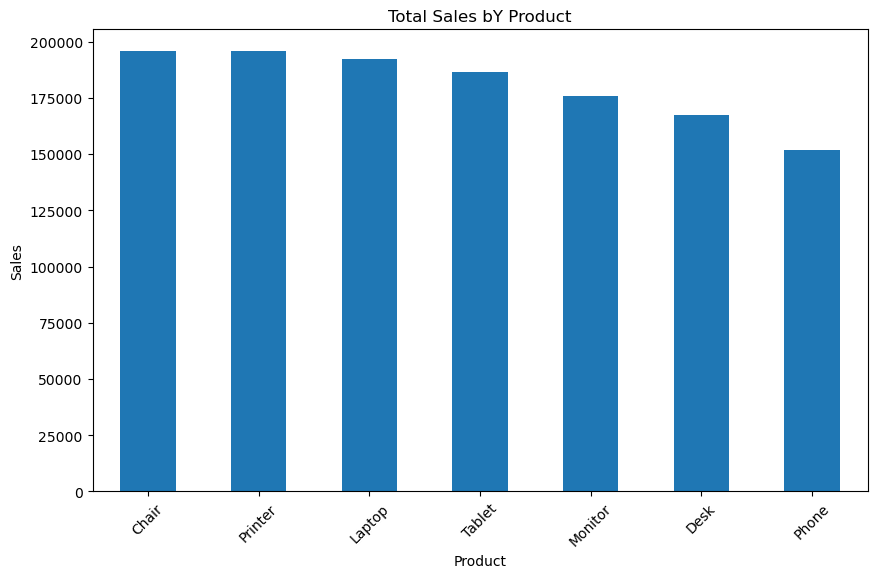

In [47]:
# Sales By Product
plt.figure(figsize=(10,6))
product_sales.plot(kind="bar")
plt.title("Total Sales bY Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [48]:
# Reporting About bar Chart
# The Bar Chart Compares total Sales Across Different Product
# product With higher Sale Contribute more to overall Revenue

In [50]:
# Payment method Analysis
payment_counts=df["PaymentMethod"].value_counts()
print(payment_counts)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


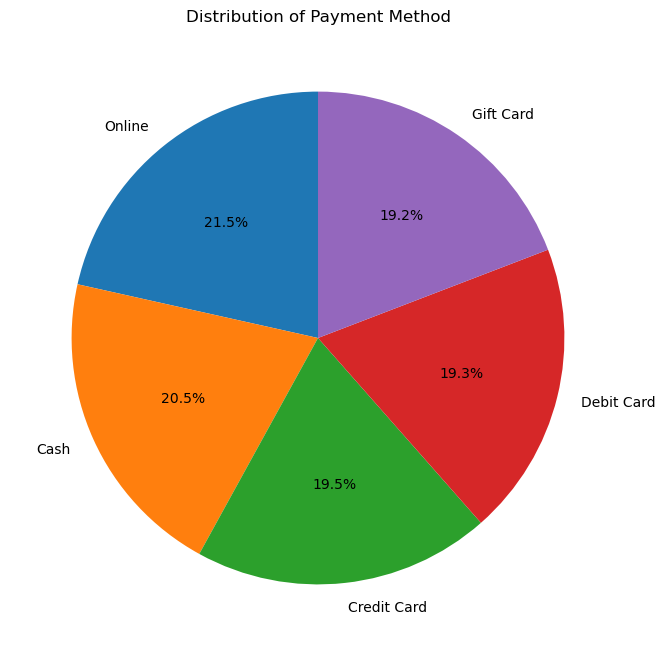

In [54]:
# Payment Method Analysis By Using Pie Chart
plt.figure(figsize=(8,8))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Payment Method")
plt.show()
    



In [55]:
# The pie Chart Shoe how Customer pay The payment
#The Largest Segment represent The mostCommonly Used Payment Method

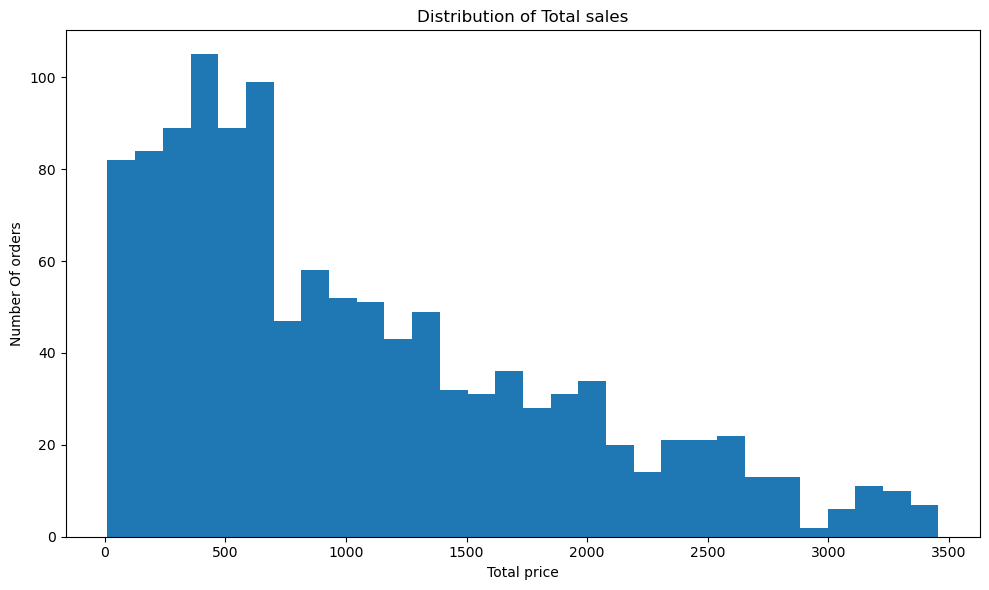

In [57]:
plt.figure(figsize=(10,6))
plt.hist(df["TotalPrice"],bins=30)
plt.title("Distribution of Total sales")
plt.xlabel("Total price")
plt.ylabel("Number Of orders")
plt.tight_layout()
plt.show()

In [58]:
# Outlier Detection
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [60]:
#cking outliers
for column in ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]:
    
    outliers, lower, upper = detect_outliers(column)
    
    print("\nColumn:", column)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", len(outliers))
# Che


Column: Quantity
Lower Bound: -1.0
Upper Bound: 7.0
Number of Outliers: 0

Column: UnitPrice
Lower Bound: -317.1987499999999
Upper Bound: 1024.8312499999997
Number of Outliers: 0

Column: ItemsInCart
Lower Bound: -0.5
Upper Bound: 11.5
Number of Outliers: 0

Column: TotalPrice
Lower Bound: -1341.4125
Upper Bound: 3330.4075
Number of Outliers: 8


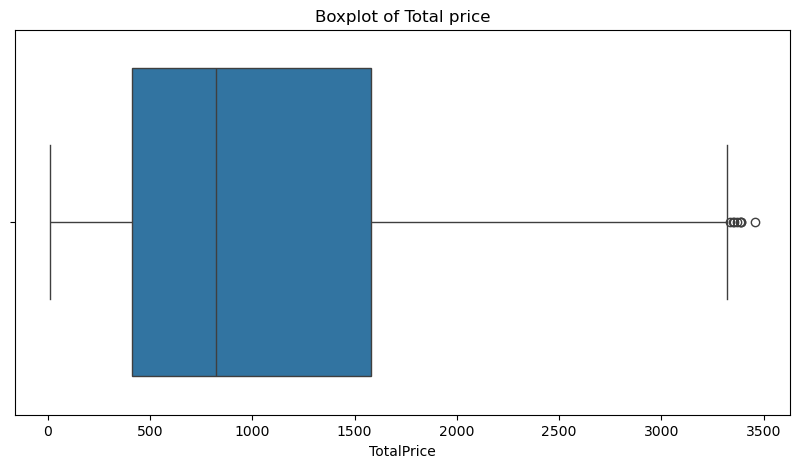

In [62]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["TotalPrice"])
plt.title("Boxplot of Total price")
plt.xlabel("TotalPrice")
plt.show()


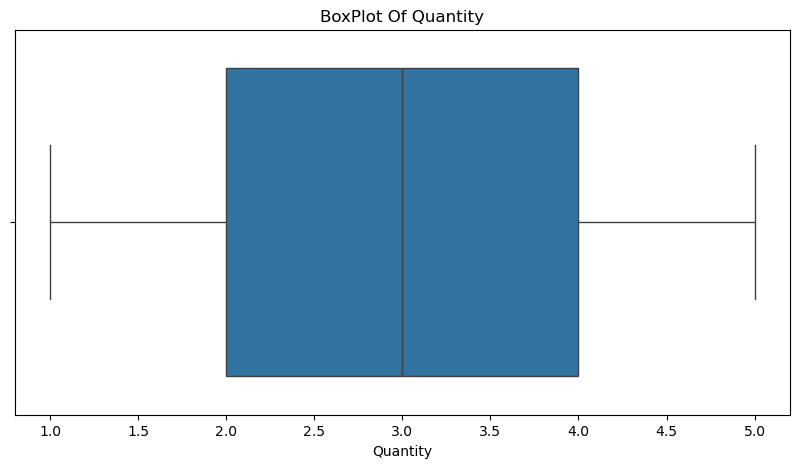

In [66]:
#Box plot Of Quantity
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Quantity"])
plt.title("BoxPlot Of Quantity")
plt.xlabel("Quantity")
plt.show()

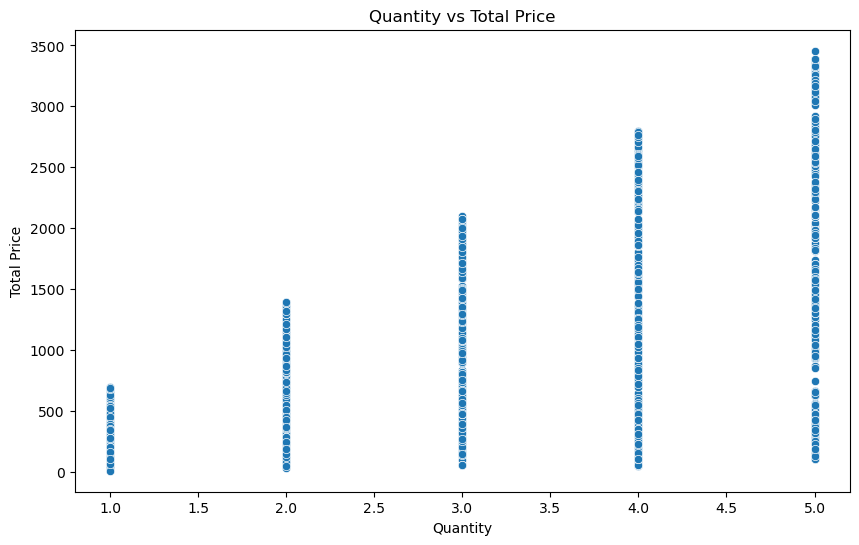

In [67]:
# Quantity Vs total price By Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Quantity",
    y="TotalPrice"
)
plt.title("Quantity vs Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.show()

In [68]:
# The Scatterplot Show The Relationship Between Quantity Purchased And Total order values
# Generally High Quantity leads to High Total Price, Although unit Price Also Affect The unit Price

In [70]:
# Sales By Order Status
status_sales=df.groupby("OrderStatus")["TotalPrice"].sum()
status_sales

OrderStatus
Cancelled    276396.21
Delivered    242600.32
Pending      256328.15
Returned     243277.70
Shipped      246159.58
Name: TotalPrice, dtype: float64

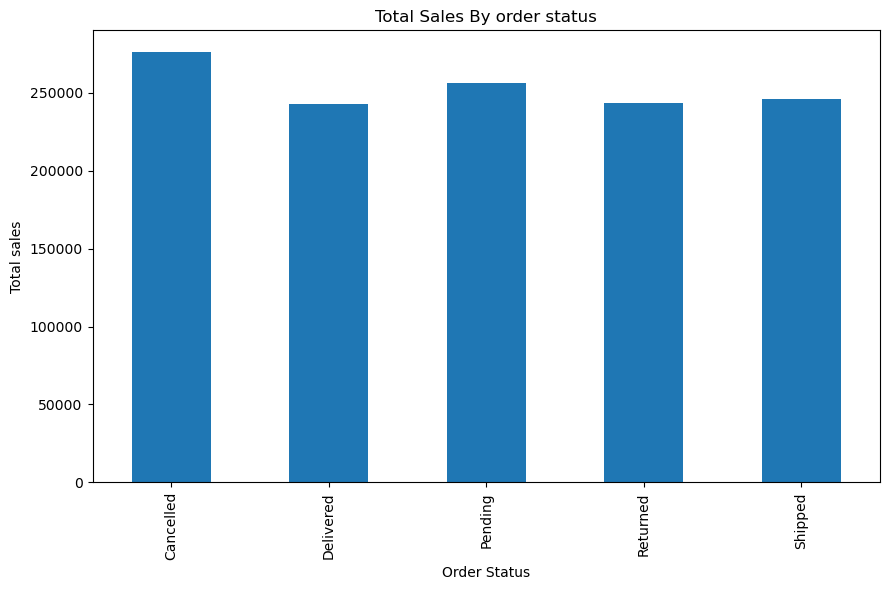

In [72]:
# represented by Bar Grapg
plt.figure(figsize=(9,6))
status_sales.plot(kind="bar")
plt.title("Total Sales By order status")
plt.xlabel("Order Status")
plt.ylabel("Total sales")
plt.tight_layout()
plt.show()

In [73]:
#Refferal Analysis
referral_counts = df["ReferralSource"].value_counts()

referral_counts

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

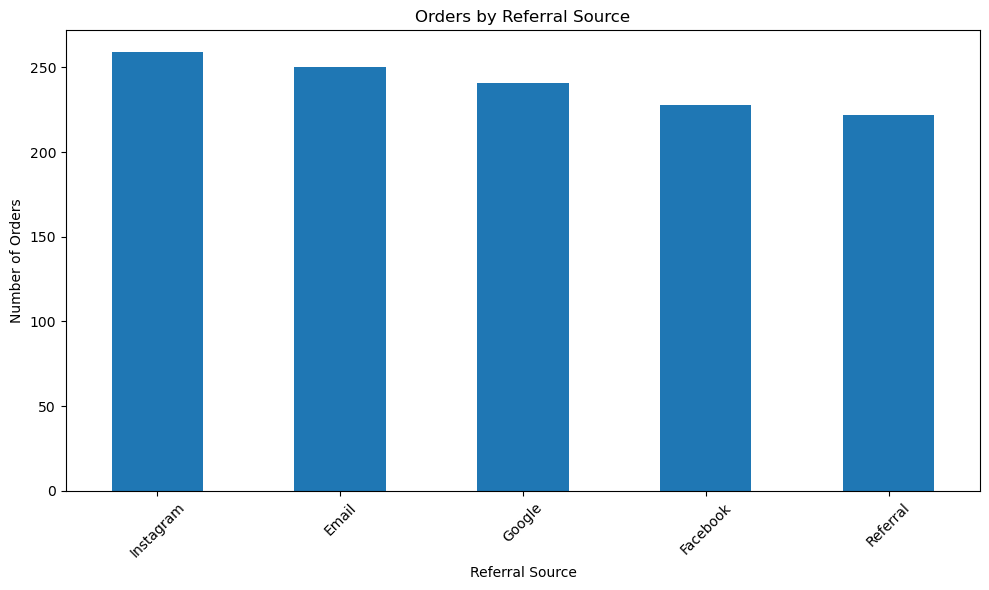

In [74]:

plt.figure(figsize=(10, 6))

referral_counts.plot(kind="bar")

plt.title("Orders by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [75]:
# Monthly sales
df["Month"] = df["Date"].dt.to_period("M").astype(str)

In [76]:

# Calculation
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

monthly_sales.head()

Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
Name: TotalPrice, dtype: float64

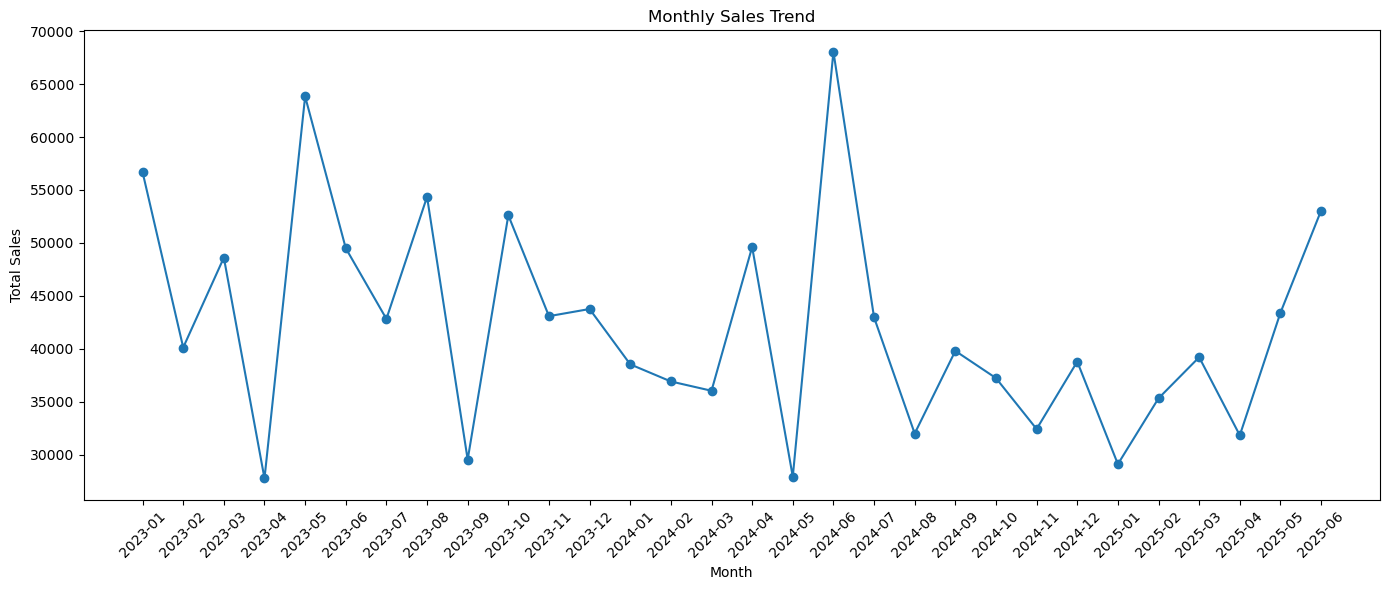

In [77]:
# represented By LIne chart
plt.figure(figsize=(14, 6))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [78]:
#Report
#The monthly sales trend shows how revenue changes over time.
#Increasing or decreasing periods can help identify strong and weak sales periods.

In [79]:

# Correlation Analysis
correlation_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

correlation = df[correlation_columns].corr()

correlation

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


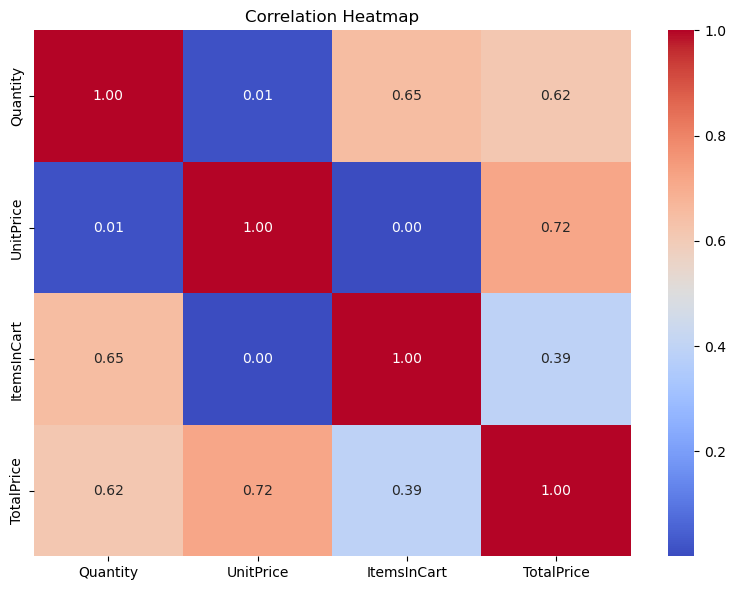

In [80]:

# represented By Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [81]:

#Report
#The correlation heatmap shows how numerical variables move together.
#Values close to +1 indicate a strong positive relationship, while values close to -1 indicate a strong negative relationship.

In [82]:
# Overall KPIS
total_orders = df["OrderID"].nunique()
total_customers = df["CustomerID"].nunique()
total_sales = df["TotalPrice"].sum()
average_order_value = df["TotalPrice"].mean()
total_quantity = df["Quantity"].sum()

print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Sales:", round(total_sales, 2))
print("Average Order Value:", round(average_order_value, 2))
print("Total Quantity Sold:", total_quantity)

Total Orders: 1200
Total Customers: 1189
Total Sales: 1264761.96
Average Order Value: 1053.97
Total Quantity Sold: 3535


In [83]:

# Best salling product
best_product = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("Best Selling Product:")
print(best_product.head(1))

Best Selling Product:
Product
Chair    195620.11
Name: TotalPrice, dtype: float64


In [84]:

# Final dataSet Checking
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Dataset Shape: (1200, 17)

Missing Values:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
CalculatedTotal    0
PriceDifference    0
Month              0
dtype: int64

Duplicate Rows:
0
